## **Install Keras & Tensorflow**

In [0]:
!pip install --upgrade tensorflow

## **Check assigned GPU**

In [1]:
!nvidia-smi

Mon May 11 18:50:38 2020       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 440.82       Driver Version: 418.67       CUDA Version: 10.1     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|===============================+======================+======================|
|   0  Tesla K80           Off  | 00000000:00:04.0 Off |                    0 |
| N/A   65C    P8    32W / 149W |      0MiB / 11441MiB |      0%      Default |
+-------------------------------+----------------------+----------------------+
                                                                               
+-----------------------------------------------------------------------------+
| Processes:                                                       GPU Memory |
|  GPU  

##**Download  & explore 20newsgroups dataset**


In [2]:
from sklearn.datasets import fetch_20newsgroups
twenty_train = fetch_20newsgroups(subset='train')  #, remove=('headers', 'footers', 'quotes'))
print("Catergories")
print(twenty_train.target_names) #prints all the categories
print("-------------")
twenty_train.target_names 
print("First dataset's sample")
print("\n".join(twenty_train.data[0].split("\n")))
print("------------")
print("First dataset's sample category: ",twenty_train.target[0])

Catergories
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']
-------------
First dataset's sample
From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this 

## **Split dataset into train (70%) & validation (30%)**

In [0]:
from sklearn.model_selection import train_test_split  
X_train, X_val, y_train, y_val = train_test_split(twenty_train.data, twenty_train.target, test_size=0.3, random_state=12547392)

In [4]:
len(X_train)

7919

## **Use spacy for sentence splitting & tokenization**

In [0]:
import spacy
nlp = spacy.load('en_core_web_sm',disable=["tagger", "parser","ner"])
from spacy.lang.en.stop_words import STOP_WORDS
nlp.add_pipe(nlp.create_pipe('sentencizer')) 

X_train_tokenized = []
for idx in range(len(X_train)):
  doc = nlp(X_train[idx])
  tokens = []
  for sent in doc.sents:
    for tok in sent:
      if '\n' in tok.text or "\t" in tok.text or "--" in tok.text or "*" in tok.text or tok.text.lower() in STOP_WORDS:
        continue
      if tok.text.strip():  
        tokens.append(tok.text.replace('"',"'").strip())
  X_train_tokenized.append(tokens)

X_val_tokenized = []
for idx in range(len(X_val)):
  doc = nlp(X_val[idx])
  tokens = []
  for sent in doc.sents:
    for tok in sent:
      if '\n' in tok.text or "\t" in tok.text or "--" in tok.text or "*" in tok.text or tok.text.lower() in STOP_WORDS:
        continue
      if tok.text.strip():
        tokens.append(tok.text.replace('"',"'").strip())
  X_val_tokenized.append(tokens)

In [6]:
for item in X_train_tokenized[:2]:
  print(item)
  print()

[':', 'kastle@wpi', '.', 'WPI.EDU', '(', 'Jacques', 'W', 'Brouillette', ')', 'Subject', ':', ':', 'WARNING', '.....', '(please', 'read', ')', '...', 'Organization', ':', 'Worcester', 'Polytechnic', 'Institute', 'Lines', ':', '8', 'Distribution', ':', 'world', 'NNTP', '-', 'Posting', '-', 'Host', ':', 'wpi.wpi.edu', 'Keywords', ':', 'BRICK', ',', 'TRUCK', ',', 'DANGER', 'plase', 'cease', 'discussion', '.', 'fail', 'people', 'feel', 'need', 'expound', 'issue', 'days', 'days', 'end', '.', 'areas', 'meant', 'type', 'discussion', '.', 'feel', 'need', 'things', ',', 'thought', '.', 'Thanks', '.', ':', 'want', 'things', 'world', ',', '58', 'Plymouth', 'small', ':', ':', 'OPEC', 'nation', 'fuel', '.', 'good', ':', ':', 'thing', '.', 'Car', 'Smashers', 'home', 'sulk', '.', ':', ':', 'Jacques', 'Brouillette', 'Manufacturing', 'Engineering', ':']

[':', 'hallam@dscomsa.desy.de', '(', 'Phill', 'Hallam', '-', 'Baker', ')', 'Subject', ':', ':', 'Tories', 'win', "'", "lottery'", '...', 'Clinton', 'GS

## **Create tf*IDF features**

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

#Use unigram & bi-gram tf*idf features
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features = 5000,sublinear_tf=True)

X_train_tfidf = vectorizer.fit_transform([" ".join(x) for x in X_train_tokenized])
X_val_tfidf = vectorizer.transform([" ".join(x) for x in X_val_tokenized])
print(X_train_tfidf.shape)

(7919, 5000)


In [0]:
# Reduce dimensionality using svd 5000 --> 500
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=500, random_state=4321)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd = svd.transform(X_val_tfidf)

## **Logistic Regression baseline**

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

clf = LogisticRegression(solver="liblinear")
clf.fit(X_train_svd, y_train)

predictions = clf.predict(X_val_svd)
print(classification_report(y_val, predictions, target_names=twenty_train.target_names))

                          precision    recall  f1-score   support

             alt.atheism       0.94      0.81      0.87       160
           comp.graphics       0.65      0.78      0.71       165
 comp.os.ms-windows.misc       0.84      0.83      0.83       189
comp.sys.ibm.pc.hardware       0.68      0.71      0.69       168
   comp.sys.mac.hardware       0.82      0.75      0.78       182
          comp.windows.x       0.86      0.85      0.86       168
            misc.forsale       0.79      0.82      0.81       182
               rec.autos       0.84      0.83      0.84       181
         rec.motorcycles       0.94      0.91      0.92       184
      rec.sport.baseball       0.85      0.91      0.88       169
        rec.sport.hockey       0.91      0.93      0.92       175
               sci.crypt       0.97      0.93      0.95       177
         sci.electronics       0.73      0.74      0.73       173
                 sci.med       0.89      0.90      0.89       181
         

## **Custom Keras callback for calculating f1, precision, recall at the end of each epoch** 

In [0]:
import tensorflow as tf
from sklearn.metrics import f1_score, recall_score, precision_score
import numpy as np
import os


class Metrics(tf.keras.callbacks.Callback):
    def __init__(self, valid_data):
        super(Metrics, self).__init__()
        self.validation_data = valid_data

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_predict = np.argmax(self.model.predict(self.validation_data[0]), -1)
        val_targ = self.validation_data[1]
        if len(val_targ.shape) == 2 and val_targ.shape[1] != 1:
            val_targ = np.argmax(val_targ, -1)
        val_targ = tf.cast(val_targ,dtype=tf.float32)
        

        _val_f1 = f1_score(val_targ, val_predict,average="weighted")
        _val_recall = recall_score(val_targ, val_predict,average="weighted")
        _val_precision = precision_score(val_targ, val_predict,average="weighted")

        logs['val_f1'] = _val_f1
        logs['val_recall'] = _val_recall
        logs['val_precision'] = _val_precision
        print(" — val_f1: %f — val_precision: %f — val_recall: %f" % (_val_f1, _val_precision, _val_recall))
        return

## **Convert labels to 1-hot vectors**

In [0]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
target_list = twenty_train.target_names
y_train_1_hot = lb.fit_transform([target_list[x] for x in y_train])
y_val_1_hot = lb.transform([target_list[x] for x in y_val])

## **MLP classifier in Keras using tf*idf features**

In [24]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

with tf.device('/device:GPU:0'):


  model = Sequential()
  model.add(Dense(512, input_dim=X_train_svd.shape[1] , activation='relu'))
  model.add(Dropout(0.5))
  model.add(Dense(256,  activation='relu'))
  model.add(Dropout(0.5))
  model.add(Dense(len(twenty_train.target_names),  activation='softmax'))

  print(model.summary())
  model.compile(loss='categorical_crossentropy',
                    optimizer=Adam(lr=0.001),
                    metrics=["accuracy"])

  if not os.path.exists('./checkpoints'):
    os.makedirs('./checkpoints')

  checkpoint = ModelCheckpoint('checkpoints/weights.hdf5',
                                                 monitor='val_f1', 
                                                 mode='max', verbose=2,
                                                 save_best_only=True,
                                                 save_weights_only=True)

  history = model.fit(X_train_svd, y_train_1_hot,
                validation_data=(X_val_svd, y_val_1_hot),
                batch_size=256,
                epochs=100,
                shuffle=True,
                callbacks=[Metrics(valid_data=(X_val_svd, y_val_1_hot)),
                checkpoint])

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_6 (Dense)              (None, 512)               256512    
_________________________________________________________________
dropout_2 (Dropout)          (None, 512)               0         
_________________________________________________________________
dense_7 (Dense)              (None, 256)               131328    
_________________________________________________________________
dropout_3 (Dropout)          (None, 256)               0         
_________________________________________________________________
dense_8 (Dense)              (None, 20)                5140      
Total params: 392,980
Trainable params: 392,980
Non-trainable params: 0
_________________________________________________________________
None
Epoch 1/100
27/31 [=========================>....] - ETA: 0s - loss: 2.9556 - accuracy: 0.1606 — val_f1: 0.52

/usr/local/lib/python3.6/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


 — val_f1: 0.768241 — val_precision: 0.797960 — val_recall: 0.779676

Epoch 00002: val_f1 improved from 0.52658 to 0.76824, saving model to checkpoints/weights.hdf5
31/31 [==============================] - 0s 11ms/step - loss: 2.5628 - accuracy: 0.4444 - val_loss: 2.0703 - val_accuracy: 0.7797 - val_f1: 0.7682 - val_recall: 0.7797 - val_precision: 0.7980
Epoch 3/100
27/31 [=========================>....] - ETA: 0s - loss: 1.6714 - accuracy: 0.6612 — val_f1: 0.807980 — val_precision: 0.819820 — val_recall: 0.809131

Epoch 00003: val_f1 improved from 0.76824 to 0.80798, saving model to checkpoints/weights.hdf5
31/31 [==============================] - 0s 11ms/step - loss: 1.6209 - accuracy: 0.6703 - val_loss: 1.0827 - val_accuracy: 0.8091 - val_f1: 0.8080 - val_recall: 0.8091 - val_precision: 0.8198
Epoch 4/100
27/31 [=========================>....] - ETA: 0s - loss: 0.9651 - accuracy: 0.7678 — val_f1: 0.835489 — val_precision: 0.839614 — val_recall: 0.835935

Epoch 00004: val_f1 improved

## **Visualize Model's Training History**


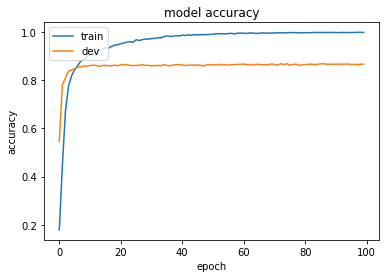

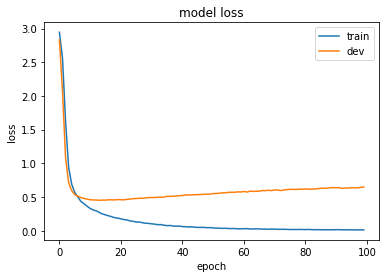

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt


# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper right')
plt.show()

## **Evaluate performance of tf-idf MLP model**

In [38]:
import warnings
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

with tf.device('/device:GPU:0'):

  model = Sequential()
  model.add(Dense(512, input_dim=X_val_svd.shape[1] , activation='relu'))
  model.add(Dense(256,  activation='relu'))
  model.add(Dense(len(twenty_train.target_names),  activation='softmax'))
  #load weights from the pre-trained model
  model.load_weights("checkpoints/weights.hdf5")
  model.compile(loss='categorical_crossentropy',
                    optimizer=Adam(lr=0.001),
                    metrics=["accuracy"])

  predictions = np.argmax(model.predict(X_val_svd), -1)
  print(classification_report(y_val, predictions, target_names=twenty_train.target_names))

                          precision    recall  f1-score   support

             alt.atheism       0.90      0.89      0.90       160
           comp.graphics       0.72      0.75      0.73       165
 comp.os.ms-windows.misc       0.84      0.83      0.83       189
comp.sys.ibm.pc.hardware       0.67      0.80      0.73       168
   comp.sys.mac.hardware       0.87      0.75      0.80       182
          comp.windows.x       0.92      0.89      0.90       168
            misc.forsale       0.79      0.85      0.82       182
               rec.autos       0.87      0.83      0.85       181
         rec.motorcycles       0.93      0.89      0.91       184
      rec.sport.baseball       0.91      0.91      0.91       169
        rec.sport.hockey       0.95      0.94      0.95       175
               sci.crypt       0.97      0.96      0.97       177
         sci.electronics       0.80      0.76      0.78       173
                 sci.med       0.86      0.94      0.90       181
         

# **Text classification with embedding centroids**

## **Download, unzip & load fasttext word embeddings**

In [15]:
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz

--2020-05-11 19:03:44--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 104.22.75.142, 104.22.74.142, 2606:4700:10::6816:4a8e, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|104.22.75.142|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4503593528 (4.2G) [application/octet-stream]
Saving to: ‘cc.en.300.bin.gz’

cc.en.300.bin.gz    100%[===================>]   4.19G  14.0MB/s    in 5m 18s  

2020-05-11 19:09:03 (13.5 MB/s) - ‘cc.en.300.bin.gz’ saved [4503593528/4503593528]



In [0]:
!gzip -d cc.en.300.bin.gz

In [0]:
from gensim.models.wrappers import FastText

fasttext = FastText.load_fasttext_format('cc.en.300.bin')

## **Calculate centroids**

In [0]:
#Calculate centroid function

import numpy as np
from spacy.lang.en.stop_words import STOP_WORDS


def text_centroid(text, model):
    
    text_vec =[]
    counter = 0
    for word in text:
        if word in STOP_WORDS:
          continue         
        try:
            if counter == 0:
                text_vec = model[word.lower()]
            else:
                text_vec = np.add(text_vec, model[word.lower()])
            counter+=1
        except:
            pass
    
    return np.asarray(text_vec) / counter

In [0]:
# Calculate centroids for train and test documents

import numpy as np 

X_train_centroids = []
for sentence in X_train_tokenized:
    X_train_centroids.append(text_centroid(sentence,fasttext))   
X_train_centroids = np.stack(X_train_centroids, axis=0)

X_val_centroids = []
for sentence in X_val_tokenized:
    X_val_centroids.append(text_centroid(sentence,fasttext))   
X_val_centroids = np.stack(X_val_centroids, axis=0)

In [33]:
X_train_centroids.shape

(7919, 300)

## **MLP text classifier in Keras with fasttext centroids**

In [36]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

with tf.device('/device:GPU:0'):

  model2 = Sequential()
  model2.add(Dense(1024, input_dim=X_train_centroids.shape[1] , activation='relu'))
  model2.add(Dropout(0.3))
  model2.add(Dense(1024,  activation='relu'))
  model2.add(Dropout(0.3))
  model2.add(Dense(512,  activation='relu'))
  model2.add(Dropout(0.3))
  model2.add(Dense(len(twenty_train.target_names),  activation='softmax'))

  print(model2.summary())
  model2.compile(loss='categorical_crossentropy',optimizer=Adam(lr=0.001),
                    metrics=["accuracy"])
  

  if not os.path.exists('./checkpoints'):
    os.makedirs('./checkpoints')

  checkpoint = ModelCheckpoint('checkpoints/weights2.hdf5',
                                                 monitor='val_f1', 
                                                 mode='max', verbose=2,
                                                 save_best_only=True,
                                                 save_weights_only=True)

  history2 = model2.fit(X_train_centroids, y_train_1_hot,
                validation_data=(X_val_centroids, y_val_1_hot),
                batch_size=256,
                epochs=100,
                shuffle=True,
                callbacks=[Metrics(valid_data=(X_val_centroids, y_val_1_hot)),
                checkpoint])

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_19 (Dense)             (None, 1024)              308224    
_________________________________________________________________
dropout_10 (Dropout)         (None, 1024)              0         
_________________________________________________________________
dense_20 (Dense)             (None, 1024)              1049600   
_________________________________________________________________
dropout_11 (Dropout)         (None, 1024)              0         
_________________________________________________________________
dense_21 (Dense)             (None, 512)               524800    
_________________________________________________________________
dropout_12 (Dropout)         (None, 512)               0         
_________________________________________________________________
dense_22 (Dense)             (None, 20)               

/usr/local/lib/python3.6/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


25/31 [=======================>......] - ETA: 0s - loss: 2.4033 - accuracy: 0.2169 — val_f1: 0.238498 — val_precision: 0.363427 — val_recall: 0.292784

Epoch 00002: val_f1 improved from 0.13798 to 0.23850, saving model to checkpoints/weights2.hdf5
31/31 [==============================] - 0s 14ms/step - loss: 2.3459 - accuracy: 0.2305 - val_loss: 2.0738 - val_accuracy: 0.2928 - val_f1: 0.2385 - val_recall: 0.2928 - val_precision: 0.3634
Epoch 3/100
25/31 [=======================>......] - ETA: 0s - loss: 2.0035 - accuracy: 0.3161 — val_f1: 0.391321 — val_precision: 0.493768 — val_recall: 0.433873

Epoch 00003: val_f1 improved from 0.23850 to 0.39132, saving model to checkpoints/weights2.hdf5
31/31 [==============================] - 0s 15ms/step - loss: 1.9740 - accuracy: 0.3261 - val_loss: 1.7407 - val_accuracy: 0.4339 - val_f1: 0.3913 - val_recall: 0.4339 - val_precision: 0.4938
Epoch 4/100
25/31 [=======================>......] - ETA: 0s - loss: 1.7167 - accuracy: 0.4092 — val_f1: 0.4

## **Visualize Model's Training History**

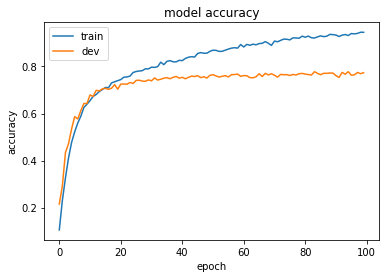

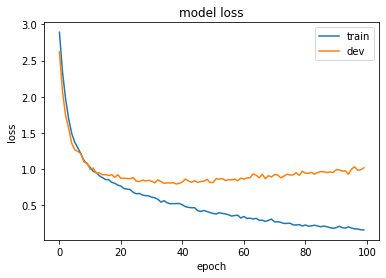

In [37]:
%matplotlib inline
import matplotlib.pyplot as plt


# summarize history for accuracy
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper right')
plt.show()

## **Evaluate performance of fasttext centroids MLP model**

In [41]:
import warnings
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

with tf.device('/device:GPU:0'):

  model2 = Sequential()
  model2.add(Dense(1024, input_dim=X_train_centroids.shape[1] , activation='relu'))
  model2.add(Dense(1024,  activation='relu'))
  model2.add(Dense(512,  activation='relu'))
  model2.add(Dense(len(twenty_train.target_names),  activation='softmax'))
  #load weights from the pre-trained model
  model2.load_weights("checkpoints/weights2.hdf5")
  model2.compile(loss='categorical_crossentropy',
                    optimizer=Adam(lr=0.001),
                    metrics=["accuracy"])

  predictions = np.argmax(model2.predict(X_val_centroids), -1)
  print(classification_report(y_val, predictions, target_names=twenty_train.target_names))

                          precision    recall  f1-score   support

             alt.atheism       0.73      0.74      0.73       160
           comp.graphics       0.61      0.65      0.63       165
 comp.os.ms-windows.misc       0.79      0.66      0.72       189
comp.sys.ibm.pc.hardware       0.61      0.64      0.63       168
   comp.sys.mac.hardware       0.63      0.71      0.67       182
          comp.windows.x       0.79      0.85      0.82       168
            misc.forsale       0.70      0.76      0.73       182
               rec.autos       0.81      0.81      0.81       181
         rec.motorcycles       0.90      0.83      0.86       184
      rec.sport.baseball       0.88      0.87      0.87       169
        rec.sport.hockey       0.89      0.93      0.91       175
               sci.crypt       0.87      0.85      0.86       177
         sci.electronics       0.72      0.74      0.73       173
                 sci.med       0.90      0.86      0.88       181
         